Pull SP15 data from CAISO

http://oasis.caiso.com/oasisapi/SingleZip?resultformat=6&queryname=PRC_LMP&version=1&market_run_id=DAM&node=TH_SP15_GEN-APND&startdatetime=20250101T00:00-0000&enddatetime=20250108T00:00-0000

In [25]:
#Install dependencies

import requests
import zipfile
import io
import pandas as pd
from datetime import date, datetime, timedelta
import time
import matplotlib.pyplot as plt

Matplotlib is building the font cache; this may take a moment.


Build function to batch pull CAISO LMP data from CAISO API

Intitial filtering/clean up

Note:
- Requests must not be longer than 31 days
- API requires 5 second delay between pulls

In [27]:
BASE_URL = "http://oasis.caiso.com/oasisapi/SingleZip"


def fetch_lmp(start_date, end_date, node, lmp_component):
    """
    Fetch CAISO Day-Ahead LMP data for a given node and date range.

    Parameters:
        start_date (str): Start date in 'YYYYMMDD' format
        end_date (str): End date in 'YYYYMMDD' format
        node (str): CAISO pricing node, e.g. 'TH_SP15_GEN-APND'
        lmp_component: 'LMP', 'MCC', 'MCE', 'MCL', 'MGHG'

    Returns:
        pandas.DataFrame containing all returned LMP data
    """
    
    # Convert user input strings into datetime objects
    start_dt = datetime.strptime(start_date, "%Y%m%d")
    end_dt = datetime.strptime(end_date, "%Y%m%d")

    # Store API-safe <=31 day date ranges
    date_ranges = []

    # Initialize first chunk start date
    current_start = start_dt

    # Create <=31 day date pairs until full range is covered
    while current_start < end_dt:

        # Set tentative chunk end 31 days ahead
        current_end = current_start + timedelta(days=30)

        # Cap final chunk at user-requested end date
        if current_end > end_dt:
            current_end = end_dt

        # Append formatted date pair to date_ranges list
        date_ranges.append([
            current_start.strftime("%Y%m%d"),
            current_end.strftime("%Y%m%d")
        ])

        # Move to next chunk window
        current_start = current_end

    # Store returned chunk dataframes before concatenation
    dfs = []

    # Loop through each date pair in date_ranges
    for chunk_start, chunk_end in date_ranges:

        # Build CAISO API request parameters
        params = {
            "resultformat": 6,
            "queryname": "PRC_LMP",
            "startdatetime": chunk_start + "T00:00-0000",
            "enddatetime": chunk_end + "T00:00-0000",
            "market_run_id": "DAM",
            "node": node,
            "version": 1,
        }

        # Send API request to CAISO OASIS
        response = requests.get(BASE_URL, params=params)

        # Raise exception if request fails
        if response.status_code != 200:
            raise Exception(f"Request failed: {response.status_code}")

        # Read ZIP response into memory
        z = zipfile.ZipFile(io.BytesIO(response.content))

        # Get first file name inside ZIP
        filename = z.namelist()[0]

        # Read CSV inside ZIP into dataframe
        df = pd.read_csv(z.open(filename))

        # Append chunk dataframe to dfs list
        dfs.append(df)

        # Pause script for 5.5 seconds to allow API refresh
        # CAISO API requires 5 second pauses between pulls
        time.sleep(5.5)

    # Concatenate all chunk dataframes into one dataframe
    df_all = pd.concat(dfs, ignore_index=True)

    # Filter df by user defined lmp_component
    df_all = df_all[df_all["LMP_TYPE"] == lmp_component]

    # Rename columns
    df_all = df_all.rename(columns={"INTERVALSTARTTIME_GMT": "start_datetime", "INTERVALENDTIME_GMT": "end_datetime", "MW": "price"})

    # Convert Start and end_datetime columns to datetime format
    df_all["start_datetime"] = pd.to_datetime(df_all["start_datetime"])
    df_all["end_datetime"] = pd.to_datetime(df_all["end_datetime"])

    # Parse date and hour from start_datetime column
    df_all["Start Date"] = df_all["start_datetime"].dt.date
    df_all["Start Hour"] = df_all["start_datetime"].dt.hour

    # Parse date and hour from end_datetime column
    df_all["End Date"] = df_all["end_datetime"].dt.date
    df_all["End Hour"] = df_all["end_datetime"].dt.hour

    # Sort by start_datetime
    df_all = df_all.sort_values(by=["start_datetime"])

    # Round price values
    df_all["price"] = df_all["price"].round(2)

    return df_all

Explore data structure, initial graphing

In [28]:
sp_15_da = fetch_lmp("20250101", "20250331", "TH_SP15_GEN-APND", "LMP")

(array([  5.,  10.,  17.,  16.,  11.,  10.,   6.,  32.,  18.,  15.,  22.,
         49.,  47.,  70.,  39.,  38.,  25.,  23.,  33.,  25.,  40.,  36.,
         33.,  40.,  21.,  26.,  21.,  34.,  49.,  60., 103., 154., 180.,
        160., 136., 109., 138.,  77.,  59.,  45.,  20.,  21.,  21.,  11.,
         18.,   6.,   4.,   1.,   1.,   1.]),
 array([-40.35  , -37.7324, -35.1148, -32.4972, -29.8796, -27.262 ,
        -24.6444, -22.0268, -19.4092, -16.7916, -14.174 , -11.5564,
         -8.9388,  -6.3212,  -3.7036,  -1.086 ,   1.5316,   4.1492,
          6.7668,   9.3844,  12.002 ,  14.6196,  17.2372,  19.8548,
         22.4724,  25.09  ,  27.7076,  30.3252,  32.9428,  35.5604,
         38.178 ,  40.7956,  43.4132,  46.0308,  48.6484,  51.266 ,
         53.8836,  56.5012,  59.1188,  61.7364,  64.354 ,  66.9716,
         69.5892,  72.2068,  74.8244,  77.442 ,  80.0596,  82.6772,
         85.2948,  87.9124,  90.53  ]),
 <BarContainer object of 50 artists>)

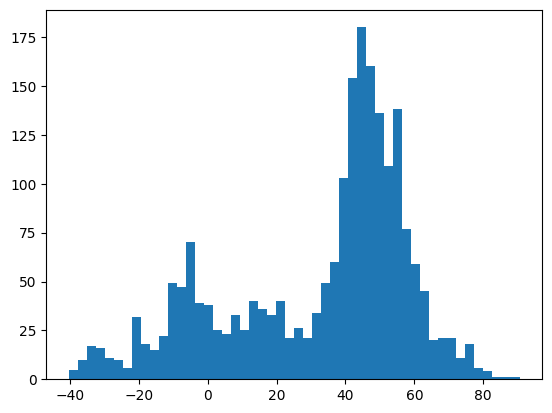

In [29]:
plt.hist(sp_15_da["price"], bins=50)